# Final Project Peramalan Penjualan Menggunakan Random Forest Regression

Notebook ini dibuat untuk proyek akhir mata kuliah peramalan. Tujuan utama notebook ini adalah memprediksi dan meramalkan `Total Sales` harian keseluruhan berdasarkan data transaksi tahun 2020-2021.

Metode utama yang digunakan adalah **Random Forest Regression** karena metode ini termasuk dalam pilihan metode tugas dan cocok untuk data tabular dengan fitur kalender, lag, dan rolling statistics. Target akhir notebook adalah forecast 30 hari setelah data historis terakhir, yaitu periode `2022-01-01` sampai `2022-01-30`.

Dataset: `dataset.csv`


## Instalasi Library

Cell berikut disediakan agar notebook dapat dijalankan di Google Colab atau environment lokal yang belum memiliki library yang dibutuhkan. Jika semua library sudah tersedia, cell ini boleh dilewati.


In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn

## Ruang Lingkup Notebook

Notebook ini berfokus pada:

1. Memuat dan memahami dataset transaksi.
2. Membersihkan dan menyiapkan data tanggal.
3. Melakukan agregasi data menjadi penjualan harian keseluruhan.
4. Melengkapi kalender harian dari `2020-01-01` sampai `2021-12-31`.
5. Membuat fitur time series seperti lag, rolling average, rolling standard deviation, dan fitur kalender.
6. Membagi data secara kronologis menjadi data latih dan data uji.
7. Membandingkan Random Forest Regression dengan baseline sederhana `Lag-7`.
8. Mengevaluasi model menggunakan MAE, RMSE, MAPE, dan R2.
9. Menampilkan visualisasi hasil prediksi, error, feature importance, dan forecast 30 hari ke depan.

Notebook ini disiapkan untuk review dosen sebelum penyusunan paper dan PPT.


In [2]:
# Import library yang dibutuhkan
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [3]:
# Load dataset
DATA_PATH = "dataset.csv"

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (9360, 9)


,Invoice Date,Product,Region,Retailer,Sales Method,State,Price per Unit,Total Sales,Units Sold
0,01-01-2020,Men's Street Footwear,Northeast,Foot Locker,In-store,New York,50,6000,120
1,02-01-2020,Men's Athletic Footwear,Northeast,Foot Locker,In-store,New York,50,5000,100
2,03-01-2020,Women's Street Footwear,Northeast,Foot Locker,In-store,New York,40,4000,100
3,04-01-2020,Women's Athletic Footwear,Northeast,Foot Locker,In-store,New York,45,3825,85
4,05-01-2020,Men's Apparel,Northeast,Foot Locker,In-store,New York,60,5400,90


## Deskripsi Dataset

Dataset berisi data transaksi penjualan dengan kolom:

- `Invoice Date`: tanggal transaksi.
- `Product`: jenis produk.
- `Region`: wilayah penjualan.
- `Retailer`: nama retailer.
- `Sales Method`: metode penjualan.
- `State`: lokasi/state.
- `Price per Unit`: harga per unit.
- `Total Sales`: total nilai penjualan.
- `Units Sold`: jumlah unit terjual.

Karena tujuan proyek adalah peramalan, data transaksi akan diagregasi menjadi data penjualan harian berdasarkan `Invoice Date`.


In [4]:
# Basic data inspection
print("Informasi dataset:")
df.info()

print("\nJumlah missing value per kolom:")
display(df.isna().sum().to_frame("missing_values"))

print(f"\nJumlah baris duplikat: {df.duplicated().sum()}")

print("\nStatistik deskriptif kolom numerik:")
display(df.describe())

categorical_columns = ["Product", "Region", "Retailer", "Sales Method", "State"]
print("\nJumlah nilai unik pada kolom kategorikal:")
display(df[categorical_columns].nunique().to_frame("unique_values"))


Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 9360 entries, 0 to 9359
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Invoice Date    9360 non-null   str  
 1   Product         9360 non-null   str  
 2   Region          9360 non-null   str  
 3   Retailer        9360 non-null   str  
 4   Sales Method    9360 non-null   str  
 5   State           9360 non-null   str  
 6   Price per Unit  9360 non-null   int64
 7   Total Sales     9360 non-null   int64
 8   Units Sold      9360 non-null   int64
dtypes: int64(3), str(6)
memory usage: 658.3 KB

Jumlah missing value per kolom:


,missing_values
Invoice Date,0
Product,0
Region,0
Retailer,0
Sales Method,0
State,0
Price per Unit,0
Total Sales,0
Units Sold,0



Jumlah baris duplikat: 0

Statistik deskriptif kolom numerik:


,Price per Unit,Total Sales,Units Sold
count,"9,360.00","9,360.00","9,360.00"
mean,44.74,921.93,25.85
std,14.51,"1,413.84",21.59
min,7.00,0.00,0.00
25%,35.00,42.00,11.00
50%,45.00,95.00,18.00
75%,55.00,"1,463.00",35.00
max,110.00,"8,250.00",128.00



Jumlah nilai unik pada kolom kategorikal:


,unique_values
Product,6
Region,5
Retailer,6
Sales Method,3
State,48


In [5]:
# Parse date dan cleaning dasar
numeric_columns = ["Price per Unit", "Total Sales", "Units Sold"]

# Konversi tanggal menggunakan format eksplisit DD-MM-YYYY
df["Invoice Date"] = pd.to_datetime(df["Invoice Date"], format="%d-%m-%Y", errors="coerce")

# Pastikan kolom numerik terbaca sebagai angka
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Urutkan data berdasarkan tanggal
df = df.sort_values("Invoice Date").reset_index(drop=True)

print(f"Jumlah tanggal invalid: {df['Invoice Date'].isna().sum()}")
print(f"Tanggal minimum: {df['Invoice Date'].min().date()}")
print(f"Tanggal maksimum: {df['Invoice Date'].max().date()}")
print(f"Jumlah tanggal unik: {df['Invoice Date'].nunique()}")
print("\nMissing value setelah konversi:")
display(df[["Invoice Date", *numeric_columns]].isna().sum().to_frame("missing_values"))


Jumlah tanggal invalid: 0
Tanggal minimum: 2020-01-01
Tanggal maksimum: 2021-12-31
Jumlah tanggal unik: 724

Missing value setelah konversi:


,missing_values
Invoice Date,0
Price per Unit,0
Total Sales,0
Units Sold,0


## Persiapan Kolom Tanggal

Kolom `Invoice Date` dikonversi menjadi tipe datetime menggunakan format `%d-%m-%Y`, karena format tanggal pada dataset adalah DD-MM-YYYY.

Data kemudian diurutkan berdasarkan tanggal agar proses pembagian train-test dapat dilakukan secara kronologis, bukan acak.

Pembagian kronologis penting dalam peramalan agar model tidak menggunakan informasi dari masa depan untuk memprediksi masa lalu.


In [6]:
# EDA ringkas berdasarkan kategori
sales_by_product = df.groupby("Product", as_index=False)["Total Sales"].sum().sort_values("Total Sales", ascending=False)
sales_by_region = df.groupby("Region", as_index=False)["Total Sales"].sum().sort_values("Total Sales", ascending=False)
sales_by_method = df.groupby("Sales Method", as_index=False)["Total Sales"].sum().sort_values("Total Sales", ascending=False)
sales_by_retailer = df.groupby("Retailer", as_index=False)["Total Sales"].sum().sort_values("Total Sales", ascending=False)

print("Total Sales berdasarkan Product:")
display(sales_by_product)

print("Total Sales berdasarkan Region:")
display(sales_by_region)

print("Total Sales berdasarkan Sales Method:")
display(sales_by_method)

print("Total Sales berdasarkan Retailer:")
display(sales_by_retailer)


Total Sales berdasarkan Product:


,Product,Total Sales
2,Men's Street Footwear,1999192
3,Women's Apparel,1720630
1,Men's Athletic Footwear,1468116
5,Women's Street Footwear,1224756
0,Men's Apparel,1192682
4,Women's Athletic Footwear,1023899


Total Sales berdasarkan Region:


,Region,Total Sales
4,West,2329193
1,Northeast,1863429
3,Southeast,1631786
2,South,1446722
0,Midwest,1358145


Total Sales berdasarkan Sales Method:


,Sales Method,Total Sales
0,In-store,3566650
2,Outlet,2595011
1,Online,2467614


Total Sales berdasarkan Retailer:


,Retailer,Total Sales
5,West Gear,2429793
1,Foot Locker,2067310
3,Sports Direct,1789845
2,Kohl's,1021226
4,Walmart,677702
0,Amazon,643399


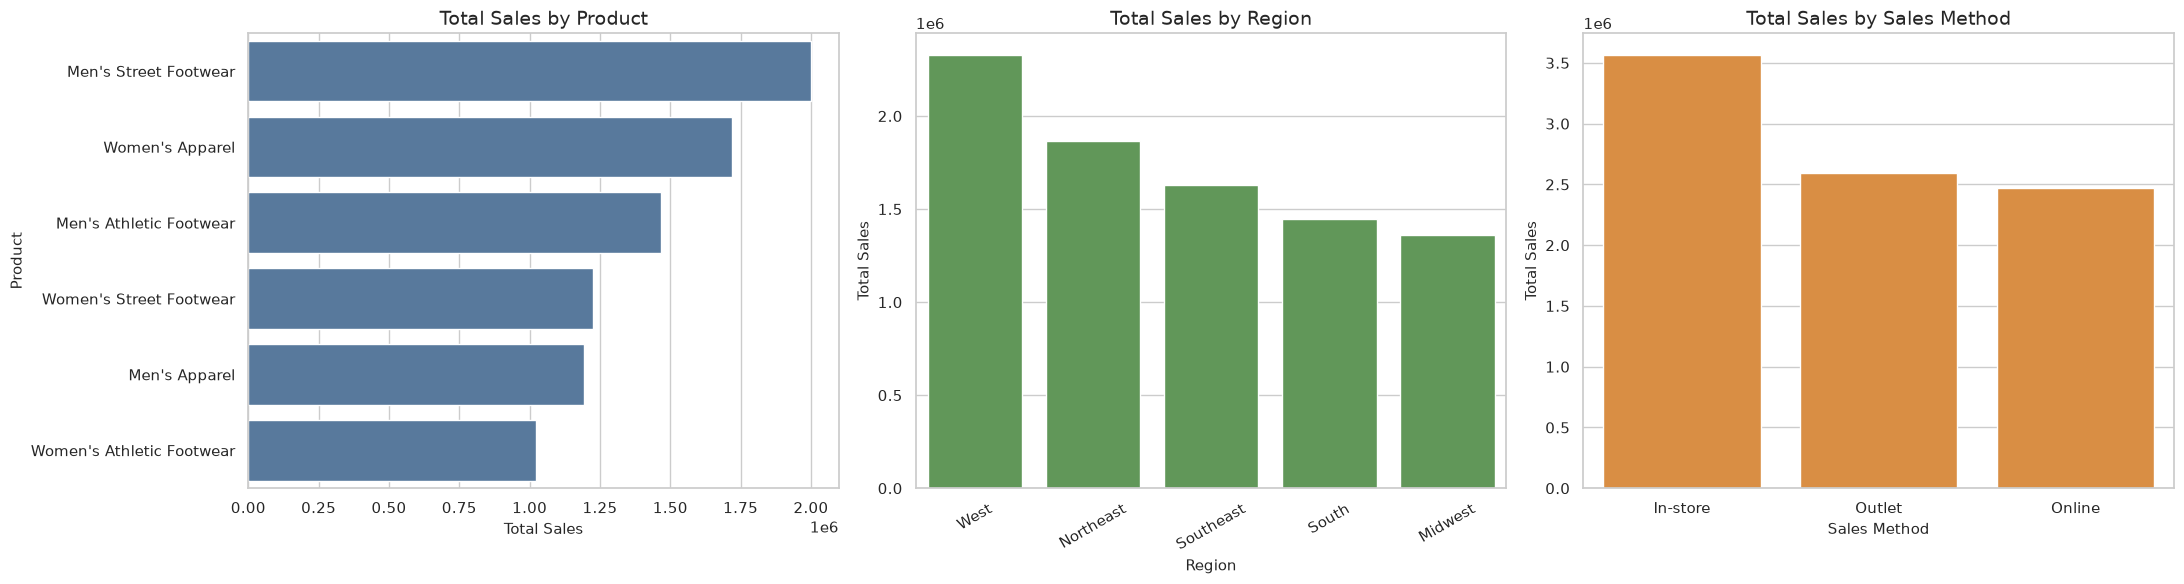

In [7]:
# Visualisasi EDA kategori
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(data=sales_by_product, x="Total Sales", y="Product", ax=axes[0], color="#4C78A8")
axes[0].set_title("Total Sales by Product")
axes[0].set_xlabel("Total Sales")
axes[0].set_ylabel("Product")

sns.barplot(data=sales_by_region, x="Region", y="Total Sales", ax=axes[1], color="#59A14F")
axes[1].set_title("Total Sales by Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Total Sales")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=sales_by_method, x="Sales Method", y="Total Sales", ax=axes[2], color="#F28E2B")
axes[2].set_title("Total Sales by Sales Method")
axes[2].set_xlabel("Sales Method")
axes[2].set_ylabel("Total Sales")

plt.tight_layout()
plt.show()


In [8]:
# Agregasi transaksi menjadi data penjualan harian keseluruhan
transaction_daily = (
    df.groupby("Invoice Date", as_index=False)["Total Sales"]
    .sum()
    .rename(columns={"Invoice Date": "Date"})
    .sort_values("Date")
    .reset_index(drop=True)
)

# Kalender harian lengkap untuk periode data historis yang digunakan
calendar = pd.DataFrame({
    "Date": pd.date_range(start="2020-01-01", end="2021-12-31", freq="D")
})

daily_sales = calendar.merge(transaction_daily, on="Date", how="left")
daily_sales["Total Sales"] = daily_sales["Total Sales"].fillna(0)

missing_dates = daily_sales.loc[
    ~daily_sales["Date"].isin(transaction_daily["Date"]),
    "Date"
]

print("Preview data harian:")
display(daily_sales.head())

print("Akhir data harian:")
display(daily_sales.tail())

print(f"Shape data harian: {daily_sales.shape}")
print(f"Rentang tanggal: {daily_sales['Date'].min().date()} sampai {daily_sales['Date'].max().date()}")
print(f"Jumlah baris harian: {len(daily_sales)}")
print(f"Memenuhi minimum 300 data: {len(daily_sales) >= 300}")
print(f"Jumlah tanggal tanpa transaksi yang diisi Total Sales = 0: {len(missing_dates)}")

if len(missing_dates) > 0:
    print("Tanggal tanpa transaksi:")
    display(pd.DataFrame({"Date": missing_dates.dt.date}))


Preview data harian:


,Date,Total Sales
0,2020-01-01,"8,452.00"
1,2020-01-02,"6,894.00"
2,2020-01-03,"6,325.00"
3,2020-01-04,"6,150.00"
4,2020-01-05,"7,079.00"


Akhir data harian:


,Date,Total Sales
726,2021-12-27,"6,024.00"
727,2021-12-28,"3,010.00"
728,2021-12-29,"2,112.00"
729,2021-12-30,"1,679.00"
730,2021-12-31,"1,988.00"


Shape data harian: (731, 2)
Rentang tanggal: 2020-01-01 sampai 2021-12-31
Jumlah baris harian: 731
Memenuhi minimum 300 data: True
Jumlah tanggal tanpa transaksi yang diisi Total Sales = 0: 7
Tanggal tanpa transaksi:


,Date
59,2020-02-29
284,2020-10-11
285,2020-10-12
286,2020-10-13
287,2020-10-14
288,2020-10-15
289,2020-10-16


## Agregasi Harian

Data awal berbentuk transaksi, sehingga satu tanggal dapat memiliki banyak transaksi. Untuk kebutuhan peramalan time series, data diagregasi menjadi penjualan harian keseluruhan berdasarkan `Invoice Date`.

Target prediksi adalah `Total Sales` harian. Kalender harian dilengkapi dari `2020-01-01` sampai `2021-12-31`. Tanggal yang tidak memiliki transaksi tercatat diisi dengan `Total Sales = 0`, sehingga fitur lag seperti `sales_lag_7` benar-benar merujuk pada 7 hari kalender sebelumnya.


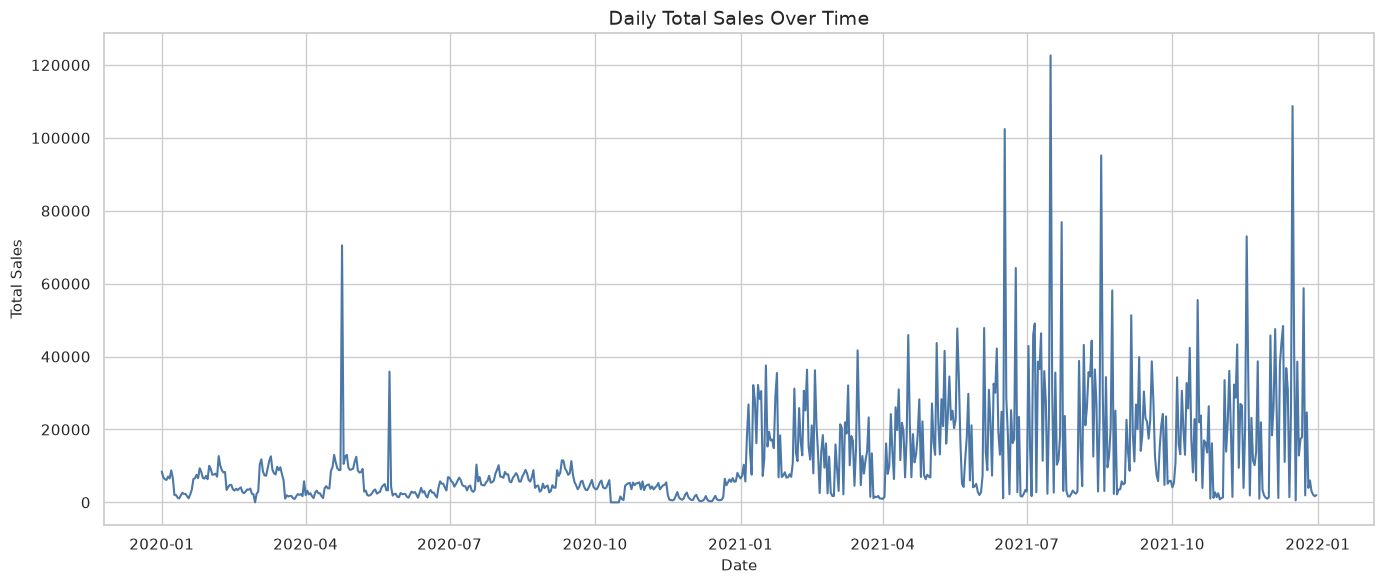

In [9]:
# Plot tren total sales harian
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_sales, x="Date", y="Total Sales", color="#4C78A8", linewidth=1.5)
plt.title("Daily Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()


## Pola Penjualan Harian

Grafik penjualan harian digunakan untuk melihat pola umum data, seperti fluktuasi, tren, dan kemungkinan lonjakan penjualan.

Karena nilai penjualan berubah dari waktu ke waktu, model membutuhkan fitur historis seperti nilai penjualan beberapa hari sebelumnya dan rata-rata penjualan periode sebelumnya.


In [10]:
# Feature engineering time series
model_data = daily_sales.copy()

# Calendar features yang tersedia untuk data historis dan masa depan
model_data["dayofweek"] = model_data["Date"].dt.dayofweek
model_data["month"] = model_data["Date"].dt.month
model_data["quarter"] = model_data["Date"].dt.quarter
model_data["year"] = model_data["Date"].dt.year
model_data["dayofmonth"] = model_data["Date"].dt.day
model_data["is_weekend"] = (model_data["dayofweek"] >= 5).astype(int)

# Lag features dari Total Sales
for lag in [1, 2, 3, 7, 14, 30]:
    model_data[f"sales_lag_{lag}"] = model_data["Total Sales"].shift(lag)

# Rolling features: shift(1) agar tidak memakai target hari yang sedang diprediksi
model_data["sales_roll_mean_3"] = model_data["Total Sales"].shift(1).rolling(window=3).mean()
model_data["sales_roll_mean_7"] = model_data["Total Sales"].shift(1).rolling(window=7).mean()
model_data["sales_roll_mean_14"] = model_data["Total Sales"].shift(1).rolling(window=14).mean()
model_data["sales_roll_mean_30"] = model_data["Total Sales"].shift(1).rolling(window=30).mean()
model_data["sales_roll_std_7"] = model_data["Total Sales"].shift(1).rolling(window=7).std()
model_data["sales_roll_std_14"] = model_data["Total Sales"].shift(1).rolling(window=14).std()

print(f"Shape sebelum drop NaN: {model_data.shape}")
model_data = model_data.dropna().reset_index(drop=True)
print(f"Shape setelah drop NaN: {model_data.shape}")
print(f"Jumlah NaN pada data model: {model_data.isna().sum().sum()}")

feature_columns = [
    "dayofweek", "month", "quarter", "year", "dayofmonth", "is_weekend",
    "sales_lag_1", "sales_lag_2", "sales_lag_3", "sales_lag_7", "sales_lag_14", "sales_lag_30",
    "sales_roll_mean_3", "sales_roll_mean_7", "sales_roll_mean_14", "sales_roll_mean_30",
    "sales_roll_std_7", "sales_roll_std_14"
]
target_column = "Total Sales"

print("Daftar fitur yang digunakan:")
for feature in feature_columns:
    print(f"- {feature}")

model_data.head()


Shape sebelum drop NaN: (731, 20)
Shape setelah drop NaN: (701, 20)
Jumlah NaN pada data model: 0
Daftar fitur yang digunakan:
- dayofweek
- month
- quarter
- year
- dayofmonth
- is_weekend
- sales_lag_1
- sales_lag_2
- sales_lag_3
- sales_lag_7
- sales_lag_14
- sales_lag_30
- sales_roll_mean_3
- sales_roll_mean_7
- sales_roll_mean_14
- sales_roll_mean_30
- sales_roll_std_7
- sales_roll_std_14


,Date,Total Sales,dayofweek,month,quarter,year,dayofmonth,is_weekend,sales_lag_1,sales_lag_2,sales_lag_3,sales_lag_7,sales_lag_14,sales_lag_30,sales_roll_mean_3,sales_roll_mean_7,sales_roll_mean_14,sales_roll_mean_30,sales_roll_std_7,sales_roll_std_14
0,2020-01-31,"10,036.00",4,1,1,2020,31,0,"6,337.00","7,260.00","6,505.00","6,627.00","1,730.00","8,452.00","6,700.67","7,300.29","5,721.93","5,083.40","1,129.73","2,553.91"
1,2020-02-01,"9,141.00",5,2,1,2020,1,1,"10,036.00","6,337.00","7,260.00","9,359.00","1,102.00","6,894.00","7,877.67","7,787.29","6,315.21","5,136.20","1,473.57","2,519.77"
2,2020-02-02,"7,556.00",6,2,1,2020,2,1,"9,141.00","10,036.00","6,337.00","8,319.00","2,162.00","6,325.00","8,504.67","7,756.14","6,889.43","5,211.10","1,436.66","2,125.51"
3,2020-02-03,"7,659.00",0,2,1,2020,3,0,"7,556.00","9,141.00","10,036.00","6,695.00","3,453.00","6,150.00","8,911.00","7,647.14","7,274.71","5,252.13","1,415.63","1,634.93"
4,2020-02-04,"7,876.00",1,2,1,2020,4,0,"7,659.00","7,556.00","9,141.00","6,505.00","6,393.00","7,079.00","8,118.67","7,784.86","7,575.14","5,302.43","1,353.07","1,209.81"


## Feature Engineering

Model Random Forest tidak memahami urutan waktu secara langsung seperti model time series klasik. Oleh karena itu, pola waktu diubah menjadi fitur numerik, yaitu:

- Fitur kalender: hari dalam minggu, bulan, kuartal, tahun, tanggal dalam bulan, dan indikator akhir pekan.
- Fitur lag: nilai `Total Sales` pada 1, 2, 3, 7, 14, dan 30 hari sebelumnya.
- Fitur rolling: rata-rata 3, 7, 14, dan 30 hari serta standar deviasi 7 dan 14 hari dari periode historis sebelumnya.

Semua fitur lag dan rolling dibuat dari data masa lalu agar tidak terjadi data leakage. Pada rolling feature, notebook ini menggunakan `.shift(1)` sebelum `.rolling(...)` supaya nilai target pada hari yang sedang diprediksi tidak ikut masuk sebagai fitur.

Fitur `Average Price`, `units_lag_1`, dan `units_lag_7` tidak digunakan sebagai fitur utama karena nilainya tidak tersedia secara pasti ketika melakukan forecast 30 hari ke depan.


In [11]:
# Chronological train-test split
X = model_data[feature_columns]
y = model_data[target_column]
dates = model_data["Date"]

split_index = int(len(model_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]
dates_train = dates.iloc[:split_index]
dates_test = dates.iloc[split_index:]

print(f"Training period: {dates_train.min().date()} sampai {dates_train.max().date()}")
print(f"Testing period: {dates_test.min().date()} sampai {dates_test.max().date()}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Training period: 2020-01-31 sampai 2021-08-12
Testing period: 2021-08-13 sampai 2021-12-31
X_train shape: (560, 18)
X_test shape: (141, 18)
y_train shape: (560,)
y_test shape: (141,)


## Pembagian Data

Data dibagi secara kronologis: data lama digunakan sebagai data latih dan data terbaru digunakan sebagai data uji.

Pendekatan ini sesuai untuk forecasting karena model dilatih menggunakan data masa lalu dan diuji pada periode setelahnya.


In [12]:
# Fungsi evaluasi dan baseline model
def mean_absolute_percentage_error_safe(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def symmetric_mean_absolute_percentage_error_safe(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denominator = np.abs(y_true) + np.abs(y_pred)
    mask = denominator != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(2 * np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100

def weighted_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denominator = np.sum(np.abs(y_true))
    if denominator == 0:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / denominator * 100

def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error_safe(y_true, y_pred)
    smape = symmetric_mean_absolute_percentage_error_safe(y_true, y_pred)
    wmape = weighted_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, mape, smape, wmape, r2

metrics_rows = []

# Baseline Lag-7: prediksi hari ini = penjualan 7 hari kalender sebelumnya
baseline_pred = X_test["sales_lag_7"]
baseline_mae, baseline_rmse, baseline_mape, baseline_smape, baseline_wmape, baseline_r2 = evaluate_regression(y_test, baseline_pred)

metrics_rows.append({
    "Model": "Baseline Lag-7",
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "MAPE (%)": baseline_mape,
    "sMAPE (%)": baseline_smape,
    "WMAPE (%)": baseline_wmape,
    "R2 Score": baseline_r2
})

metrics_df = pd.DataFrame(metrics_rows)
metrics_df


,Model,MAE,RMSE,MAPE (%),sMAPE (%),WMAPE (%),R2 Score
0,Baseline Lag-7,"16,238.45","21,119.75",296.35,91.88,82.59,-0.39


In [13]:
# Train model utama: Random Forest Regression
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae, rf_rmse, rf_mape, rf_smape, rf_wmape, rf_r2 = evaluate_regression(y_test, rf_pred)

metrics_rows.append({
    "Model": "Random Forest",
    "MAE": rf_mae,
    "RMSE": rf_rmse,
    "MAPE (%)": rf_mape,
    "sMAPE (%)": rf_smape,
    "WMAPE (%)": rf_wmape,
    "R2 Score": rf_r2
})

metrics_df = pd.DataFrame(metrics_rows)
metrics_df


,Model,MAE,RMSE,MAPE (%),sMAPE (%),WMAPE (%),R2 Score
0,Baseline Lag-7,"16,238.45","21,119.75",296.35,91.88,82.59,-0.39
1,Random Forest,"8,613.36","12,743.03",178.51,55.98,43.81,0.50


## Pemilihan Model dan Evaluasi

Notebook ini menggunakan **Random Forest Regression** sebagai metode utama karena:

1. Random Forest merupakan ensemble dari banyak tree sehingga hasilnya cenderung lebih stabil.
2. Random Forest cocok untuk data tabular dengan fitur lag, rolling, dan kalender.
3. Random Forest lebih mudah dijelaskan dibandingkan model yang lebih kompleks untuk kebutuhan responsi.
4. Model dapat memberikan feature importance untuk interpretasi.

Baseline `Lag-7` tetap ditampilkan hanya sebagai pembanding naïf, yaitu prediksi hari ini menggunakan nilai penjualan 7 hari kalender sebelumnya. Baseline ini membantu menunjukkan apakah Random Forest memberi perbaikan dibandingkan aturan sederhana.

Evaluasi utama menggunakan MAE dan RMSE karena keduanya berada pada skala nilai penjualan. R2 ditampilkan sebagai metrik tambahan untuk melihat proporsi variasi yang dapat dijelaskan model. MAPE tetap ditampilkan karena umum digunakan dalam forecasting, tetapi perlu dibaca hati-hati pada data harian yang memiliki nilai aktual kecil atau nol. Untuk melengkapi interpretasi, notebook ini juga menampilkan sMAPE dan WMAPE. Kedua metrik tersebut lebih stabil dibanding MAPE biasa ketika nilai aktual sangat kecil.

Standar interpretasi MAPE seperti Lewis dapat digunakan sebagai referensi umum, tetapi tidak selalu cocok untuk data harian dengan banyak nilai aktual kecil. Oleh karena itu, penilaian model pada notebook ini lebih ditekankan pada MAE, RMSE, R2, sMAPE, WMAPE, dan perbandingan terhadap baseline.


In [14]:
# Tabel hasil prediksi pada data uji
prediction_results = pd.DataFrame({
    "Date": dates_test.values,
    "Actual Total Sales": y_test.values,
    "Predicted Total Sales": rf_pred
})

prediction_results["Error"] = prediction_results["Actual Total Sales"] - prediction_results["Predicted Total Sales"]
prediction_results["Absolute Error"] = prediction_results["Error"].abs()
prediction_results["Absolute Percentage Error"] = np.where(
    prediction_results["Actual Total Sales"] != 0,
    prediction_results["Absolute Error"] / prediction_results["Actual Total Sales"] * 100,
    np.nan
)

print("Preview hasil prediksi:")
display(prediction_results.head(20))

print("Ringkasan hasil prediksi:")
display(pd.DataFrame({
    "Metric": ["Mean Actual Sales", "Mean Predicted Sales", "Mean Absolute Error", "Max Absolute Error"],
    "Value": [
        prediction_results["Actual Total Sales"].mean(),
        prediction_results["Predicted Total Sales"].mean(),
        prediction_results["Absolute Error"].mean(),
        prediction_results["Absolute Error"].max()
    ]
}))


Preview hasil prediksi:


,Date,Actual Total Sales,Predicted Total Sales,Error,Absolute Error,Absolute Percentage Error
0,2021-08-13,"36,472.00","29,446.05","7,025.95","7,025.95",19.26
1,2021-08-14,"27,057.00","24,122.78","2,934.22","2,934.22",10.84
2,2021-08-15,"2,975.00","24,240.13","-21,265.13","21,265.13",714.79
3,2021-08-16,"22,576.00","29,641.40","-7,065.40","7,065.40",31.30
4,2021-08-17,"95,173.00","45,012.22","50,160.78","50,160.78",52.70
5,2021-08-18,"29,967.00","33,493.35","-3,526.35","3,526.35",11.77
6,2021-08-19,"3,111.00","11,633.67","-8,522.67","8,522.67",273.95
7,2021-08-20,"34,369.00","34,671.43",-302.43,302.43,0.88
8,2021-08-21,"9,612.00","11,126.69","-1,514.69","1,514.69",15.76
9,2021-08-22,"12,762.00","15,561.93","-2,799.93","2,799.93",21.94


Ringkasan hasil prediksi:


,Metric,Value
0,Mean Actual Sales,"19,662.53"
1,Mean Predicted Sales,"20,937.87"
2,Mean Absolute Error,"8,613.36"
3,Max Absolute Error,"50,579.39"


## Diagnostik MAPE Tinggi

Nilai MAPE dihitung dengan rumus `|Actual - Predicted| / Actual`. Ketika `Actual Total Sales` sangat kecil, error absolut yang sebenarnya masih wajar dapat berubah menjadi persentase error yang sangat besar. Karena itu, MAPE pada data harian dapat terlihat buruk meskipun MAE, RMSE, dan R2 sudah membaik dibanding baseline.

Analisis berikut memeriksa hubungan antara nilai aktual dan `Absolute Percentage Error`, lalu membandingkan rata-rata APE pada hari dengan penjualan rendah dan tinggi.


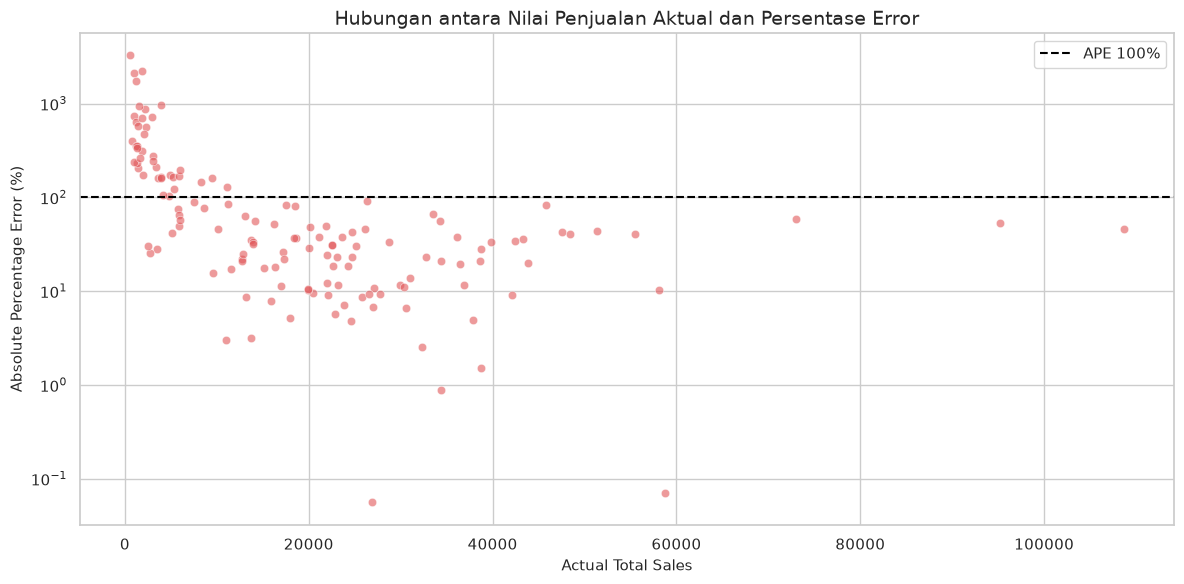

Jumlah hari dengan penjualan < 5000: 36 hari
Rata-rata APE pada hari penjualan rendah: 587.03%
Rata-rata APE pada hari penjualan tinggi: 38.45%


,Kelompok Hari,Jumlah Hari,Rata-rata APE (%),Rata-rata Actual Total Sales
0,Actual Total Sales < 5000,36,587.03,"2,300.69"
1,Actual Total Sales >= 5000,105,38.45,"25,615.16"


In [15]:
# Visualisasi hubungan antara Actual Sales dan APE (Absolute Percentage Error)
ape_plot_data = prediction_results.dropna(subset=["Absolute Percentage Error"]).copy()
ape_plot_data = ape_plot_data[ape_plot_data["Absolute Percentage Error"] > 0]

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=ape_plot_data,
    x="Actual Total Sales",
    y="Absolute Percentage Error",
    color="#E15759",
    alpha=0.6
)
plt.axhline(y=100, color="black", linestyle="--", label="APE 100%")
plt.title("Hubungan antara Nilai Penjualan Aktual dan Persentase Error")
plt.xlabel("Actual Total Sales")
plt.ylabel("Absolute Percentage Error (%)")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

# Menghitung berapa banyak hari dengan penjualan rendah yang memperbesar MAPE
low_sales_threshold = 5000
low_sales_days = prediction_results[prediction_results["Actual Total Sales"] < low_sales_threshold]
high_sales_days = prediction_results[prediction_results["Actual Total Sales"] >= low_sales_threshold]

low_sales_ape_mean = low_sales_days["Absolute Percentage Error"].mean()
high_sales_ape_mean = high_sales_days["Absolute Percentage Error"].mean()

print(f"Jumlah hari dengan penjualan < {low_sales_threshold}: {len(low_sales_days)} hari")
print(f"Rata-rata APE pada hari penjualan rendah: {low_sales_ape_mean:.2f}%")
print(f"Rata-rata APE pada hari penjualan tinggi: {high_sales_ape_mean:.2f}%")

display(pd.DataFrame({
    "Kelompok Hari": [
        f"Actual Total Sales < {low_sales_threshold}",
        f"Actual Total Sales >= {low_sales_threshold}"
    ],
    "Jumlah Hari": [len(low_sales_days), len(high_sales_days)],
    "Rata-rata APE (%)": [low_sales_ape_mean, high_sales_ape_mean],
    "Rata-rata Actual Total Sales": [
        low_sales_days["Actual Total Sales"].mean(),
        high_sales_days["Actual Total Sales"].mean()
    ]
}))


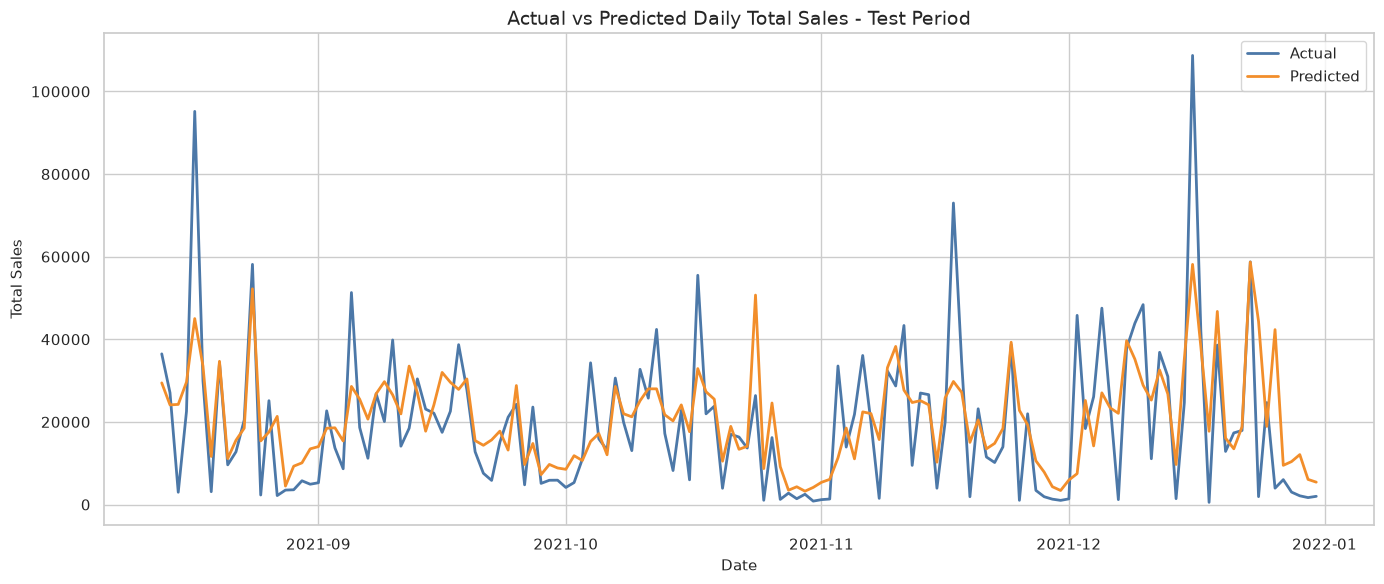

In [16]:
# Visualisasi actual vs predicted pada data testing
plt.figure(figsize=(14, 6))
plt.plot(prediction_results["Date"], prediction_results["Actual Total Sales"], label="Actual", color="#4C78A8", linewidth=2)
plt.plot(prediction_results["Date"], prediction_results["Predicted Total Sales"], label="Predicted", color="#F28E2B", linewidth=2)
plt.title("Actual vs Predicted Daily Total Sales - Test Period")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.tight_layout()
plt.show()


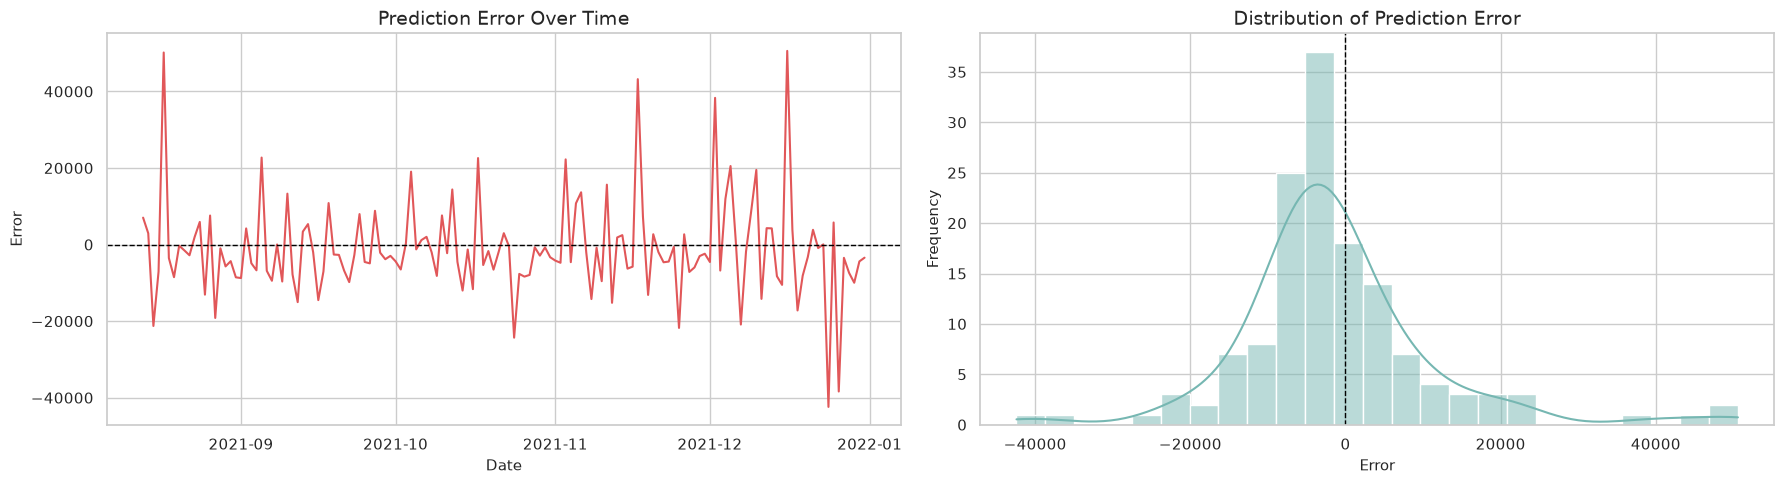

In [17]:
# Error analysis plots
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.lineplot(data=prediction_results, x="Date", y="Error", ax=axes[0], color="#E15759")
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Prediction Error Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Error")

sns.histplot(prediction_results["Error"], bins=25, kde=True, ax=axes[1], color="#76B7B2")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Distribution of Prediction Error")
axes[1].set_xlabel("Error")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


Feature importance:


,Feature,Importance
0,sales_roll_mean_3,0.39
1,sales_lag_7,0.13
2,sales_lag_1,0.08
3,dayofmonth,0.08
4,sales_lag_14,0.07
5,sales_lag_30,0.05
6,sales_lag_3,0.03
7,sales_lag_2,0.03
8,sales_roll_mean_30,0.03
9,sales_roll_mean_7,0.03


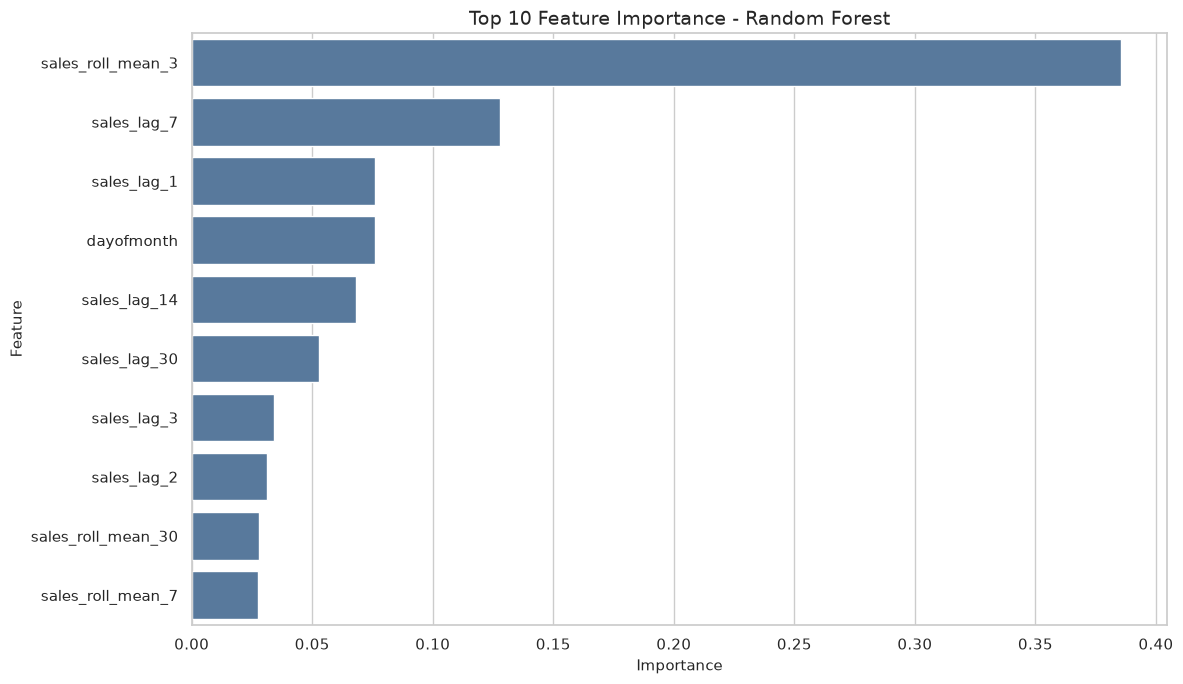

In [18]:
# Feature importance dari Random Forest
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Feature importance:")
display(feature_importance)

plt.figure(figsize=(12, 7))
sns.barplot(data=feature_importance.head(10), x="Importance", y="Feature", color="#4C78A8")
plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Interpretasi Feature Importance

Feature importance menunjukkan fitur mana yang paling banyak digunakan model dalam membuat prediksi.

Jika fitur lag atau rolling memiliki nilai importance tinggi, berarti model banyak memanfaatkan pola historis penjualan. Hal ini sesuai dengan konsep peramalan, yaitu memprediksi nilai masa depan berdasarkan pola masa lalu.


In [19]:
# Contoh 10 hasil prediksi terakhir pada data uji
prediction_results.tail(10)


,Date,Actual Total Sales,Predicted Total Sales,Error,Absolute Error,Absolute Percentage Error
131,2021-12-22,"17,920.00","18,840.20",-920.20,920.20,5.14
132,2021-12-23,"58,742.00","58,700.91",41.09,41.09,0.07
133,2021-12-24,"1,910.00","44,313.67","-42,403.67","42,403.67","2,220.09"
134,2021-12-25,"24,677.00","18,913.42","5,763.58","5,763.58",23.36
135,2021-12-26,"3,960.00","42,342.05","-38,382.05","38,382.05",969.24
136,2021-12-27,"6,024.00","9,490.20","-3,466.20","3,466.20",57.54
137,2021-12-28,"3,010.00","10,396.30","-7,386.30","7,386.30",245.39
138,2021-12-29,"2,112.00","12,086.94","-9,974.94","9,974.94",472.30
139,2021-12-30,"1,679.00","6,084.79","-4,405.79","4,405.79",262.41
140,2021-12-31,"1,988.00","5,416.94","-3,428.94","3,428.94",172.48


## Forecast 30 Hari ke Depan

Setelah model dievaluasi pada data uji, Random Forest digunakan untuk meramalkan `Total Sales` harian selama 30 hari setelah tanggal terakhir data historis. Periode forecast adalah `2022-01-01` sampai `2022-01-30`.

Forecast dilakukan secara recursive: prediksi untuk satu hari ditambahkan ke riwayat penjualan, lalu digunakan untuk membentuk fitur lag dan rolling pada hari berikutnya.


In [20]:
# Recursive forecasting 30 hari setelah data historis terakhir
def build_forecast_features(forecast_date, sales_history):
    sales_series = pd.Series(sales_history)
    return {
        "dayofweek": forecast_date.dayofweek,
        "month": forecast_date.month,
        "quarter": forecast_date.quarter,
        "year": forecast_date.year,
        "dayofmonth": forecast_date.day,
        "is_weekend": int(forecast_date.dayofweek >= 5),
        "sales_lag_1": sales_series.iloc[-1],
        "sales_lag_2": sales_series.iloc[-2],
        "sales_lag_3": sales_series.iloc[-3],
        "sales_lag_7": sales_series.iloc[-7],
        "sales_lag_14": sales_series.iloc[-14],
        "sales_lag_30": sales_series.iloc[-30],
        "sales_roll_mean_3": sales_series.iloc[-3:].mean(),
        "sales_roll_mean_7": sales_series.iloc[-7:].mean(),
        "sales_roll_mean_14": sales_series.iloc[-14:].mean(),
        "sales_roll_mean_30": sales_series.iloc[-30:].mean(),
        "sales_roll_std_7": sales_series.iloc[-7:].std(),
        "sales_roll_std_14": sales_series.iloc[-14:].std(),
    }

forecast_dates = pd.date_range(
    start=daily_sales["Date"].max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

sales_history = daily_sales["Total Sales"].tolist()
forecast_rows = []

for forecast_date in forecast_dates:
    feature_row = build_forecast_features(forecast_date, sales_history)
    X_future = pd.DataFrame([feature_row])[feature_columns]
    forecast_value = rf_model.predict(X_future)[0]
    forecast_value = max(forecast_value, 0)

    forecast_rows.append({
        "Date": forecast_date,
        "Forecasted Total Sales": forecast_value
    })
    sales_history.append(forecast_value)

forecast_results = pd.DataFrame(forecast_rows)

print(f"Jumlah baris forecast: {len(forecast_results)}")
print(f"Periode forecast: {forecast_results['Date'].min().date()} sampai {forecast_results['Date'].max().date()}")
display(forecast_results)


Jumlah baris forecast: 30
Periode forecast: 2022-01-01 sampai 2022-01-30


,Date,Forecasted Total Sales
0,2022-01-01,"11,197.14"
1,2022-01-02,"21,103.59"
2,2022-01-03,"19,240.10"
3,2022-01-04,"16,332.84"
4,2022-01-05,"22,541.90"
5,2022-01-06,"29,568.93"
6,2022-01-07,"15,986.89"
7,2022-01-08,"26,713.21"
8,2022-01-09,"29,551.27"
9,2022-01-10,"28,883.84"


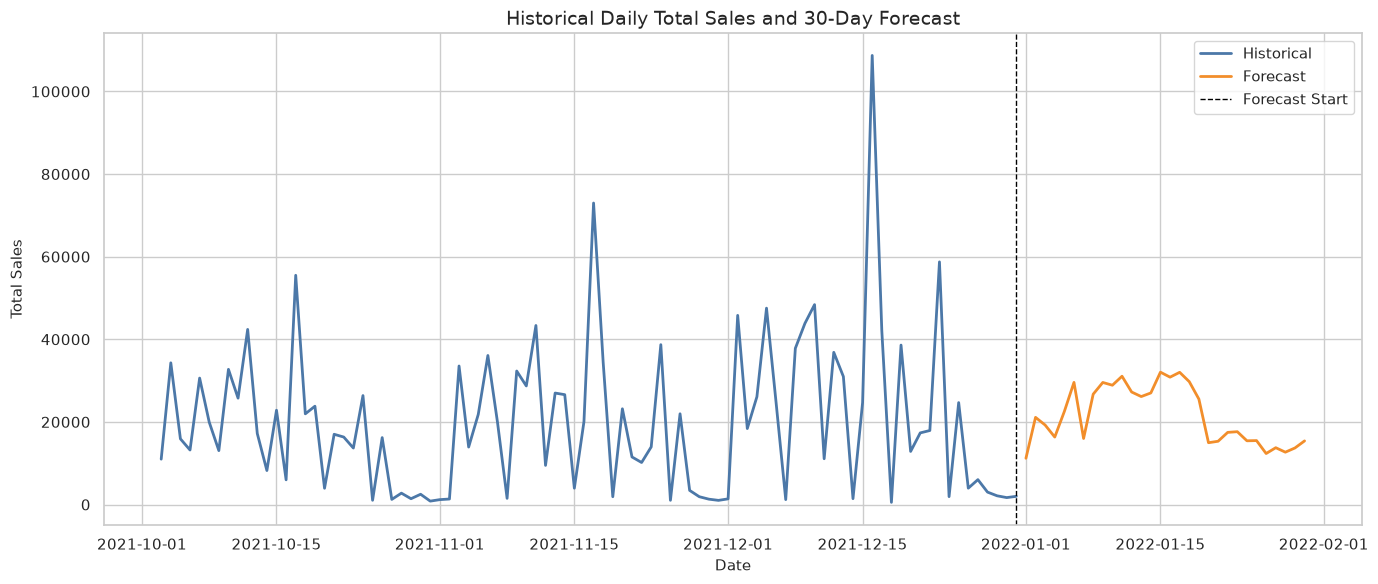

In [21]:
# Visualisasi 90 hari historis terakhir dan forecast 30 hari ke depan
historical_90 = daily_sales.tail(90).copy()

plt.figure(figsize=(14, 6))
plt.plot(historical_90["Date"], historical_90["Total Sales"], label="Historical", color="#4C78A8", linewidth=2)
plt.plot(forecast_results["Date"], forecast_results["Forecasted Total Sales"], label="Forecast", color="#F28E2B", linewidth=2)
plt.axvline(daily_sales["Date"].max(), color="black", linestyle="--", linewidth=1, label="Forecast Start")
plt.title("Historical Daily Total Sales and 30-Day Forecast")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.tight_layout()
plt.show()


## Kesimpulan

Notebook ini membangun pipeline peramalan `Total Sales` harian keseluruhan menggunakan Random Forest Regression. Data transaksi diagregasi menjadi data harian, kalender dilengkapi dari `2020-01-01` sampai `2021-12-31`, kemudian dibuat fitur kalender, lag, rolling mean, dan rolling standard deviation tanpa menggunakan informasi masa depan.

Model dievaluasi dengan split kronologis 80:20 menggunakan MAE dan RMSE sebagai metrik utama, R2 sebagai tambahan, serta MAPE, sMAPE, dan WMAPE sebagai metrik persentase error. MAPE tetap ditampilkan, tetapi interpretasinya diberi catatan karena data harian memiliki cukup banyak nilai aktual kecil yang dapat membuat persentase error melonjak. Random Forest dibandingkan dengan baseline sederhana `Lag-7`, bukan dengan metode lain, karena fokus notebook ini adalah penggunaan Random Forest sebagai metode utama.

Model Random Forest kemudian digunakan untuk melakukan recursive forecast 30 hari ke depan, yaitu `2022-01-01` sampai `2022-01-30`. Hasil forecast disajikan dalam tabel dan grafik yang menggabungkan 90 hari historis terakhir dengan 30 hari hasil ramalan.


## Checklist Review Dosen

Hal-hal yang dapat diperiksa dari notebook ini:

- Dataset berhasil dimuat dari `dataset.csv`.
- Jumlah data transaksi adalah 9.360 baris.
- Format tanggal DD-MM-YYYY berhasil dikonversi.
- Data transaksi berhasil diagregasi menjadi penjualan harian keseluruhan.
- Kalender harian lengkap dari `2020-01-01` sampai `2021-12-31`.
- Tanggal tanpa transaksi diisi `Total Sales = 0`.
- Jumlah data harian tetap memenuhi minimum 300 data.
- Fitur lag dan rolling dibuat dari data masa lalu.
- Fitur yang tidak tersedia untuk masa depan, seperti `Average Price` dan `Units Sold`, tidak digunakan sebagai fitur utama.
- Pembagian train-test dilakukan secara kronologis.
- Model baseline `Lag-7` tersedia sebagai pembanding sederhana.
- Model utama menggunakan Random Forest Regression.
- Evaluasi menggunakan MAE, RMSE, MAPE, sMAPE, WMAPE, dan R2.
- Tersedia grafik actual vs predicted.
- Tersedia error plot dan interpretasi feature importance.
- Forecast 30 hari menghasilkan tanggal berurutan dari `2022-01-01` sampai `2022-01-30`.
